# SolarIQ — Area Science Park PV plant Q2 (Trieste): power curve, forecasting & string diagnostics

The real DC-side operating data behind a **SolarIQ**-style analysis: a rooftop PV plant on
building Q2 (Basovizza campus, Trieste, 45.64°N 13.85°E), logged every 15 minutes from
2013-01-01 to 2021-11-16 (~8.9 years, no gaps, no NaNs). Dataset: *Real operating data of a
photovoltaic system installed at Area Science Park - Trieste - Italy*, CC-BY-4.0,
zenodo.org/records/7115550. Columns: per-string DC currents (8 strings on 3 inverters),
per-inverter DC voltage and back-of-panel temperature, plane-of-array irradiance, ambient
temperature. DC power per inverter is `V × Σ I`; the plant is ~14 kWp (99.9th percentile).

The arc mirrors the Kelmarsh wind SCADA notebook, adapted to PV physics — and to SolarIQ's
product pitch ("diagnoses solar underperformance to the string"):

1. **SCADA-quality pass** — grid regularity, night handling, implausible values, frozen
   sensors, and **inverter-offline events** (daytime irradiance with zero inverter voltage).
2. **Irradiance→power curve & string conformance** — the PV analog of the wind power curve:
   a temperature-corrected efficiency model for the plant, plus a per-string `I ~ G` model;
   **string conformance** flags any string producing below its fleet relationship (dead
   string, fuse cluster, shading) and the lost kWh — the exact SolarIQ diagnostic.
3. **Plant power forecasting — baselines** — persistence vs **diurnal mean** vs linear vs
   GBDT at 1 h / 6 h / 24 h. Solar's bar is different from wind's: persistence is strong at
   short horizons but hopeless at 24 h (the sun sets) — the diurnal level is the honest
   long-horizon baseline.
4. **The missing signal: future irradiance** — an *oracle* that adds `G(t+h)` (a perfect
   solar-irradiance forecast) bounds what any real system could achieve — the solar analog
   of the wind NWP oracle.
5. **ProbSparse transformer** (the `models/informer.py` module) — 1.5 h (96/48/6), 24 h
   (96/48/96), and a 24 h oracle variant whose decoder sees the true future irradiance.
6. **Anomaly & availability** — string underperformance with lost-energy accounting,
   inverter-offline hours, soiling (monthly efficiency drift), frozen sensors.

All models persist under `models/solariq_pvq2/` (`.joblib`, `.pt` + `.json`) by this
notebook itself, so the numbers below are the exact saved weights.

## 1. Setup — load the 15-minute DC-side series

`PV_Q2.csv` sits in `datasets/` (also works if placed next to the notebook). Strings:
inv1 → strings 1–3, inv2 → strings 4–6, inv3 → strings 7–8. Plant DC power (kW) =
`Σ_inv V_inv × Σ_str I_str`. Channels for the models: **P** (plant DC power, kW), **G**
(POA irradiance, W/m²), **T** (ambient temperature, °C).

In [1]:
import glob, os, sys, math, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

def resolve(name):
    for base in ("datasets", "."):
        p = os.path.join(base, name)
        if os.path.exists(p):
            return p
    return name

INV_STR = {1: [1, 2, 3], 2: [1, 2, 3], 3: [1, 2]}   # inverter -> strings

df = pd.read_csv(resolve("PV_Q2.csv"))
df["t"] = pd.to_datetime(df["date"].astype(str) + " " + df["time"])
df = df.set_index("t").sort_index()

P = 0.0
for k, strs in INV_STR.items():
    cur = sum(df[f"inv{k}_str{i}_curr"] for i in strs)
    P = P + df[f"inv{k}_volt"] * cur
df["P"] = P / 1000.0                                  # kW
df["G"] = df["irradiance"]
df["T"] = df["tamb"]
df["Tpan"] = df[[f"inv{k}_tpan" for k in INV_STR]].mean(axis=1)

CAP = float(df["P"].quantile(0.999))                  # ~rated DC, from the data
print(f"rows {len(df)} | {df.index.min()} -> {df.index.max()}")
print(f"plant DC: max {df['P'].max():.1f} kW, 99.9pct {CAP:.1f} kW, "
      f"daytime mean {df.loc[df['G']>400,'P'].mean():.1f} kW")
print(f"channels: P {df['P'].mean():.2f} kW mean | G max {df['G'].max():.1f} W/m² "
      f"| T {df['T'].min():.1f}..{df['T'].max():.1f} °C | Tpan {df['Tpan'].min():.1f}..{df['Tpan'].max():.1f} °C")

n = len(df)
i_tr, i_va = int(0.7 * n), int(0.8 * n)
print(f"split: train {i_tr} | val {i_va-i_tr} | test {n-i_va} "
      f"({df.index[i_va].date()} -> {df.index[-1].date()})")

rows 311232 | 2013-01-01 00:00:00 -> 2021-11-16 23:45:00
plant DC: max 16.1 kW, 99.9pct 14.0 kW, daytime mean 8.8 kW
channels: P 2.15 kW mean | G max 1303.5 W/m² | T -10.4..46.5 °C | Tpan -12.4..68.1 °C
split: train 217862 | val 31123 | test 62247 (2020-02-07 -> 2021-11-16)


## 2. SCADA data-quality pass (solar lens)

Night handling is the PV twist: at `G < 10 W/m²` the plant should be at zero — so daytime
points with irradiance but no power are **inverter-offline / fault candidates**, not data
gaps. Checks: grid regularity (and DST anomalies), implausible values, frozen sensors
(stuck irradiance, stuck string currents while the sun is up), and negative currents.

In [2]:
def stuck_mask(s, min_len=4):
    # True where a value is part of a run of >= min_len identical consecutive values
    # (>= 1 h at 15-min sampling). Vectorized, NaN-safe.
    same = (s == s.shift()).fillna(False)
    grp = (same != same.shift()).cumsum()
    cnt = same.groupby(grp).transform("sum")
    return same & (cnt >= min_len)

print("=== sampling & coverage ===")
dts = df.index.to_series().diff().dropna()
print(f"median dt: {dts.median()}, unique dt: {sorted(dts.unique())}")
exp = pd.date_range(df.index.min(), df.index.max(), freq="15min")
print(f"expected {len(exp)} points, have {len(df)} ({100*len(df)/len(exp):.2f}%)")
cnt = df.resample("D").size()
print(f"days with != 96 records: {int((cnt != 96).sum())} (DST would show 23/25 h days)")

print("\n=== plausibility ===")
print(f"G < 0 or > 1400: {int(((df['G']<0)|(df['G']>1400)).sum())} | P < 0: {int((df['P']<0).sum())}")
print(f"tamb outside [-30,60]: {int(((df['T']<-30)|(df['T']>60)).sum())} "
      f"| Tpan outside [-30,100]: {int(((df['Tpan']<-30)|(df['Tpan']>100)).sum())}")

print("\n=== frozen sensors (>= 1 h identical while the sun is up) ===")
day = df["G"] > 50
st_G = stuck_mask(df["G"]) & day
print(f"stuck irradiance: {round(float(st_G.sum())/4,1)} h")
for k in INV_STR:
    for i in INV_STR[k]:
        col = f"inv{k}_str{i}_curr"
        st = stuck_mask(df[col]) & (df["G"] > 100)
        if st.sum():
            print(f"  {col}: {round(float(st.sum())/4,1)} h stuck while sunny")

print("\n=== zero-voltage events: daytime (G>300) but inverter voltage ~ 0 ===")
for k in INV_STR:
    off = (df[f"inv{k}_volt"] < 50) & (df["G"] > 300)
    if off.sum() == 0:
        print(f"  inv{k}: none")
        continue
    strs_k = [f"inv{k}_str{i}_curr" for i in INV_STR[k]]
    cur = df.loc[off, strs_k].abs()
    dead = int((cur < 0.5).all(axis=1).sum())
    print(f"  inv{k}: {round(float(off.sum())/4,1)} h | {dead} pts true outage (all strings ~0 A) "
          f"vs {int(off.sum())-dead} pts with normal string currents (sensor/DAQ fault)")

=== sampling & coverage ===
median dt: 0 days 00:15:00, unique dt: [Timedelta('0 days 00:15:00')]
expected 311232 points, have 311232 (100.00%)
days with != 96 records: 0 (DST would show 23/25 h days)

=== plausibility ===
G < 0 or > 1400: 0 | P < 0: 0
tamb outside [-30,60]: 0 | Tpan outside [-30,100]: 0

=== frozen sensors (>= 1 h identical while the sun is up) ===
stuck irradiance: 0.0 h
  inv1_str1_curr: 19.5 h stuck while sunny
  inv1_str2_curr: 19.8 h stuck while sunny
  inv1_str3_curr: 652.2 h stuck while sunny
  inv2_str1_curr: 40.2 h stuck while sunny
  inv2_str2_curr: 56.2 h stuck while sunny
  inv2_str3_curr: 20.8 h stuck while sunny
  inv3_str1_curr: 26.8 h stuck while sunny
  inv3_str2_curr: 19.0 h stuck while sunny

=== zero-voltage events: daytime (G>300) but inverter voltage ~ 0 ===
  inv1: none
  inv2: 973.2 h | 2 pts true outage (all strings ~0 A) vs 3891 pts with normal string currents (sensor/DAQ fault)
  inv3: 4.8 h | 19 pts true outage (all strings ~0 A) vs 0 pts w

## 3. Irradiance → power curve & string conformance

**Plant power curve.** A PV panel's DC power is `P ≈ G × A × η`, where the efficiency
derates with temperature: `η(T) ≈ η_STC (1 + β (T − 25))`. So a temperature-corrected
linear model in `[G, G·(Tpan−25)]` is the parametric power curve (the solar analog of the
wind logistic curve), and the bin-mean `P vs G` curve is the non-parametric reference.

**String conformance (the SolarIQ diagnostic).** String current is near-linearly
proportional to irradiance (`I ≈ s·G`). Fit each string's slope on the train split, then
measure conformance on the test split: `100 × Σ I_actual / Σ I_expected`. A string with
conformance ≈ 0 is dead; ≈ 50% is a half-string/fuse-cluster fault; a dip below ~95% is an
underperformance worth a site check — with the **lost kWh** from `Σ max(0, I_expected − I)`.

power curve P = G*(0.0135 + -0.000011*(Tpan-25)) [kW per W/m²] | R² train 0.9547, test 0.8432
=== string conformance — test window AND full period (train-fit slopes) ===
 string  slope_A_per_Wm2  conf_test_%  lost_test_kwh  conf_full_%  lost_full_kwh
inv1-s3         0.004633         99.1          251.1         96.9         1704.1
inv2-s2         0.004871         97.2          239.4         97.4         1394.6
inv2-s3         0.005435         97.9          219.3         98.7         1212.1
inv3-s1         0.005238         97.1          368.3         98.7         1493.0
inv2-s1         0.005022         98.3          206.2         98.8         1178.9
inv1-s1         0.005341         99.3          279.1         99.2         1370.0
inv1-s2         0.005327         98.8          289.1         99.2         1328.7
inv3-s2         0.005130         98.3          313.2         99.3         1291.3

worst string (full period): inv1-s3 at 96.9% conformance, ≈ 1704 kWh lost over 2013-2021


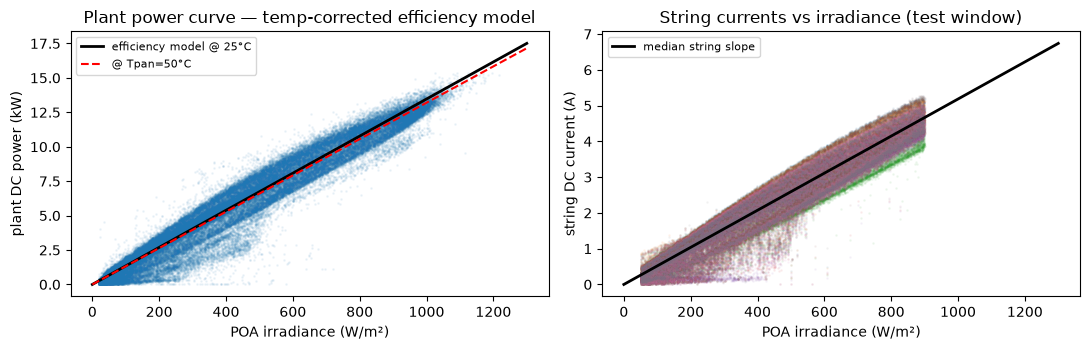

In [3]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

tr, va, te = df.iloc[:i_tr], df.iloc[i_tr:i_va], df.iloc[i_va:]

# --- plant bin-mean reference curve (non-parametric) ---
bins = defaultdict(lambda: [0.0, 0])
for G, P in zip(tr["G"], tr["P"]):
    b = round(G / 10.0) * 10
    bins[b][0] += P
    bins[b][1] += 1
ref = {b: s / n for b, (s, n) in bins.items() if n >= 50}
bins_arr = np.array(sorted(ref)); ref_arr = np.array([ref[b] for b in bins_arr])

# --- temperature-corrected efficiency model: P = a0*G + a1*G*(Tpan-25) ---
def pow_feats(d):
    return np.column_stack([d["G"].values, d["G"].values * (d["Tpan"].values - 25.0)])

m_day = tr["G"] > 20
pc = LinearRegression().fit(pow_feats(tr[m_day]), tr.loc[m_day, "P"])
r2_tr = r2_score(tr.loc[m_day, "P"], pc.predict(pow_feats(tr[m_day])))
md_test = te["G"] > 20
r2_te = r2_score(te.loc[md_test, "P"], pc.predict(pow_feats(te[md_test])))
print(f"power curve P = G*({pc.coef_[0]:.4f} + {pc.coef_[1]:.6f}*(Tpan-25)) "
      f"[kW per W/m²] | R² train {r2_tr:.4f}, test {r2_te:.4f}")

# --- per-string I ~ G fits + conformance (test window AND full period) ---
str_rows = []
for k in INV_STR:
    for i in INV_STR[k]:
        col = f"inv{k}_str{i}_curr"
        m = (tr["G"] > 50) & (tr[col] > 0.01)
        sfit = (tr.loc[m, col] * tr.loc[m, "G"]).sum() / (tr.loc[m, "G"] ** 2).sum()  # I = s*G
        def conf_lost(sub, mask_key):
            mt = sub["G"] > 50
            Ihat = sfit * sub.loc[mt, "G"]
            Iact = sub.loc[mt, col].clip(lower=0)
            conf = 100 * float(Iact.sum()) / float(Ihat.sum()) if Ihat.sum() else np.nan
            lost = float((Ihat - Iact).clip(lower=0).mul(sub.loc[mt, f"inv{k}_volt"] / 1000.0 * 0.25).sum())
            return conf, lost
        c_test, l_test = conf_lost(te, "test")
        c_full, l_full = conf_lost(df, "full")
        str_rows.append({"string": f"inv{k}-s{i}", "slope_A_per_Wm2": round(sfit, 6),
                         "conf_test_%": round(c_test, 1), "lost_test_kwh": round(l_test, 1),
                         "conf_full_%": round(c_full, 1), "lost_full_kwh": round(l_full, 1)})
st_conf = pd.DataFrame(str_rows)
print("=== string conformance — test window AND full period (train-fit slopes) ===")
print(st_conf.sort_values("conf_full_%").to_string(index=False))
worst = st_conf.sort_values("conf_full_%").iloc[0]
print(f"\nworst string (full period): {worst['string']} at {worst['conf_full_%']}% conformance, "
      f"≈ {worst['lost_full_kwh']:.0f} kWh lost over 2013-2021")

# --- figure: power curve + string behaviour ---
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
ax.scatter(tr.loc[tr["G"] > 20, "G"], tr.loc[tr["G"] > 20, "P"], s=1, alpha=0.06, rasterized=True)
Gg = np.linspace(0, 1300, 100)
ax.plot(Gg, pc.coef_[0] * Gg, "k-", lw=2, label="efficiency model @ 25°C")
ax.plot(Gg, pc.coef_[0] * Gg + pc.coef_[1] * Gg * 25, "r--", lw=1.5, label="@ Tpan=50°C")
ax.set_xlabel("POA irradiance (W/m²)"); ax.set_ylabel("plant DC power (kW)")
ax.set_title("Plant power curve — temp-corrected efficiency model"); ax.legend(fontsize=8)
ax2 = axes[1]
for k in INV_STR:
    for i in INV_STR[k]:
        col = f"inv{k}_str{i}_curr"
        mm = (te["G"] > 50) & (te["G"] < 900)
        ax2.scatter(te.loc[mm, "G"], te.loc[mm, col], s=1, alpha=0.05, rasterized=True)
ax2.plot(Gg, st_conf["slope_A_per_Wm2"].median() * Gg, "k-", lw=2, label="median string slope")
ax2.set_xlabel("POA irradiance (W/m²)"); ax2.set_ylabel("string DC current (A)")
ax2.set_title("String currents vs irradiance (test window)"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [4]:
# --- save power curve + string conformance artifacts ---
import joblib

def models_dir():
    for base in ("models", "../models"):
        if os.path.isdir(base):
            return base
    os.makedirs("models", exist_ok=True)
    return "models"

mdir = os.path.join(models_dir(), "solariq_pvq2")
os.makedirs(mdir, exist_ok=True)

pc_art = {"plant": "Area Science Park Q2 (Trieste)", "source": "zenodo 7115550 (CC-BY-4.0)",
          "capacity_kwp_999pct": round(float(CAP), 2),
          "efficiency_model": {"coef_G": round(float(pc.coef_[0]), 6),
                               "coef_GxT": round(float(pc.coef_[1]), 8),
                               "r2_train": round(float(r2_tr), 4), "r2_test": round(float(r2_te), 4)},
          "ref_curve": {"bin_edges_10Wm2": [float(b) for b in bins_arr],
                        "mean_kW": [float(v) for v in ref_arr]},
          "saved_by": "solariq_pvq2_analysis.ipynb"}
with open(os.path.join(mdir, "power_curve.json"), "w") as f:
    json.dump(pc_art, f, indent=1)

sc_art = {"strings": json.loads(st_conf.to_json(orient="records")),
          "method": "I = s*G fit on train; conformance = 100*sum(I_act)/sum(I_hat) on test",
          "saved_by": "solariq_pvq2_analysis.ipynb"}
with open(os.path.join(mdir, "string_conformance.json"), "w") as f:
    json.dump(sc_art, f, indent=1)
print("saved ->", os.path.join(mdir, "power_curve.json"), "|",
      os.path.join(mdir, "string_conformance.json"))

saved -> ../models/solariq_pvq2/power_curve.json | ../models/solariq_pvq2/string_conformance.json


## 4. Plant power forecasting — baselines

Target: plant DC power `P(t+h)` (kW) at h = 1 h / 6 h / 24 h (4 / 24 / 96 fifteen-minute
steps), 70/10/20 temporal split over the 8.9 years. Features are **history-only**: power /
irradiance / temperature lags plus calendar sines. Three honest baselines:

- **persistence** — `P(t)` → `P(t+h)`. Solar quirk: at exactly 24 h this means *same time
  yesterday*, a genuinely strong baseline (sky conditions persist day-to-day); at 6 h it is
  the worst (phase-shifted across the midday ramp); at 1 h it is near-perfect at night;
- **diurnal mean** — train mean power per hour-of-day; the honest level baseline;
- **linear / GBDT** on the lag features — with lagged irradiance they can track ramps.

In [5]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error

os.environ.setdefault("OMP_NUM_THREADS", "4")

HOURS = [1, 6, 24]
H_STEPS = [h * 4 for h in HOURS]
LAGS = [0, 1, 4, 24, 96]                              # now, 15min, 1h, 6h, 24h ago
CH3 = ["P", "G", "T"]

s = df[CH3].copy()
n = len(s)

def feats(s, h, oracle=False):
    cols = {}
    for c in CH3:
        for lag in LAGS:
            cols[f"{c}_l{lag}"] = s[c].shift(lag)
    t = s.index
    hour = t.hour + t.minute / 60
    doy = t.dayofyear
    cols["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    cols["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    cols["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    cols["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    if oracle:
        cols["G_future"] = s["G"].shift(-h)           # perfect solar forecast (leakage)
    X = pd.DataFrame(cols)
    y = s["P"].shift(-h)
    d = X.copy(); d["y"] = y
    d = d.dropna()
    return (d.drop(columns="y").values, d["y"].values, d.index)

# diurnal-mean baseline: train mean power per hour-of-day (96 bins), keyed 0..95
tr_idx = s.index[:i_tr]
diurnal = s["P"].iloc[:i_tr].groupby(tr_idx.hour * 4 + tr_idx.minute // 15).mean()

rows = []
for h in H_STEPS:
    X, y, tidx = feats(s, h)
    Xtr, ytr = X[:i_tr], y[:i_tr]
    Xte, yte = X[i_va:], y[i_va:]
    pers = np.abs(yte - Xte[:, 0])                    # persistence (feature P_l0)
    tt = tidx[i_va:] + pd.Timedelta(minutes=15 * h)   # target times of the test rows
    tbin = (tt.hour * 4 + tt.minute // 15).values
    diur = np.abs(yte - diurnal.values[tbin])
    lin = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xtr, ytr)
    idx = np.random.default_rng(0).choice(len(Xtr), size=min(len(Xtr), 80_000), replace=False)
    hgb = HistGradientBoostingRegressor(max_iter=150, learning_rate=0.1, max_leaf_nodes=31,
                                        random_state=0).fit(Xtr[idx], ytr[idx])
    rows.append({"h": f"{h//4}h", "persistence": pers.mean(), "diurnal_mean": diur.mean(),
                 "linear": mean_absolute_error(yte, lin.predict(Xte)),
                 "gbdt": mean_absolute_error(yte, hgb.predict(Xte))})

res = pd.DataFrame(rows).set_index("h")
print("=== plant DC power forecast MAE (kW) — history-only features ===")
print(res.round(2).to_string())
print("\n=== same, % of ~14 kWp ===")
print((100 * res / CAP).round(1).to_string())

=== plant DC power forecast MAE (kW) — history-only features ===
     persistence  diurnal_mean  linear  gbdt
h                                           
1h          0.84          1.34    0.84  0.49
6h          3.33          1.34    1.72  0.87
24h         0.87          1.34    1.06  0.84

=== same, % of ~14 kWp ===
     persistence  diurnal_mean  linear  gbdt
h                                           
1h           6.0           9.6     6.1   3.5
6h          23.9           9.6    12.3   6.2
24h          6.2           9.6     7.6   6.0


In [6]:
# --- save the linear models + metadata ---
saved = {}
for h in H_STEPS:
    X, y, _ = feats(s, h)
    Xtr, ytr = X[:i_tr], y[:i_tr]
    Xte, yte = X[i_va:], y[i_va:]
    m = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xtr, ytr)
    p = os.path.join(mdir, f"power_linear_h{h//4}.joblib")
    joblib.dump(m, p)
    saved[f"h{h//4}h"] = round(float(mean_absolute_error(yte, m.predict(Xte))), 3)
    print("saved", p)

meta = {"dataset": "Area Science Park PV Q2 (zenodo 7115550)", "target": "plant DC power kW",
        "split": "70/10/20 temporal", "capacity_kwp_999pct": round(float(CAP), 2),
        "features": [f"{c}_l{lag}" for c in CH3 for lag in LAGS]
        + ["hour_sin", "hour_cos", "doy_sin", "doy_cos"],
        "test_mae_kw": saved, "saved_by": "solariq_pvq2_analysis.ipynb"}
with open(os.path.join(mdir, "power_linear_metadata.json"), "w") as f:
    json.dump(meta, f, indent=1)
print("metadata ->", os.path.join(mdir, "power_linear_metadata.json"))

saved ../models/solariq_pvq2/power_linear_h1.joblib
saved ../models/solariq_pvq2/power_linear_h6.joblib


saved ../models/solariq_pvq2/power_linear_h24.joblib
metadata -> ../models/solariq_pvq2/power_linear_metadata.json


## 5. The missing signal — future irradiance (the "perfect solar forecast" oracle)

For wind the missing exogenous signal was future wind speed (an NWP forecast); for PV it is
**future irradiance** — which in reality comes from satellite/clear-sky + NWP models (the
solar forecasting industry). Adding `G(t+h)` to the *same linear features* is leakage, but
deliberately so: it is the **oracle upper bound** on what any real irradiance-informed
forecast could achieve. This quantifies the value of an irradiance forecast — the thing a
SolarIQ-grade forecasting product would sell against.

In [7]:
oracle_rows = []
for h in H_STEPS:
    X, y, _ = feats(s, h, oracle=True)
    Xtr, ytr = X[:i_tr], y[:i_tr]
    Xte, yte = X[i_va:], y[i_va:]
    m = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xtr, ytr)
    base = res.loc[f"{h//4}h", "linear"]
    oracle_rows.append({"h": f"{h//4}h", "linear_history_only": base,
                        "linear_+_G(t+h)": mean_absolute_error(yte, m.predict(Xte))})
orc = pd.DataFrame(oracle_rows).set_index("h")
print("=== MAE (kW): history-only vs + perfect future irradiance (oracle bound) ===")
print(orc.round(2).to_string())
print("\n=== % of ~14 kWp ===")
print((100 * orc / CAP).round(1).to_string())
print(f"\nvalue of a perfect 24 h irradiance forecast: "
      f"{(orc.loc['24h','linear_history_only'] - orc.loc['24h','linear_+_G(t+h)']):.2f} kW "
      f"({100*(orc.loc['24h','linear_history_only'] - orc.loc['24h','linear_+_G(t+h)'])/CAP:.1f}% of capacity)")

=== MAE (kW): history-only vs + perfect future irradiance (oracle bound) ===
     linear_history_only  linear_+_G(t+h)
h                                        
1h                  0.84             0.28
6h                  1.72             0.49
24h                 1.06             0.28

=== % of ~14 kWp ===
     linear_history_only  linear_+_G(t+h)
h                                        
1h                   6.1              2.0
6h                  12.3              3.5
24h                  7.6              2.0

value of a perfect 24 h irradiance forecast: 0.78 kW (5.6% of capacity)


## 6. ProbSparse self-attention transformer

Same `Informer` module as ETT/Kelmarsh (`models/informer.py`, Zhou et al. AAAI 2021 —
ProbSparse attention: top-u queries by sparsity, mean(V) fill, O(L²) → O(L ln L)).
Channels: **[P, G, T]** (kW, W/m², °C), standardized on the train split. Three setups:

- **96/48/6** (1.5 h ahead) — persistence is strong but the fast irradiance ramps hurt; the
  transformer can beat it by tracking ramps with the irradiance channel.
- **96/48/96** (24 h ahead) — note the persistence definition here is the *multi-step* one:
  **hold the last observed value for the whole horizon** (a flat line). That is hopeless
  across the diurnal cycle (~3.0 kW); the honest bar is the **diurnal mean** (~1.34 kW), and
  the transformer must learn the daily shape plus day-to-day carryover to beat it.
  (§4's single-point 24 h persistence — *same time yesterday* — is a different, much
  stronger baseline at 0.87 kW; both are reported, they answer different questions.)
- **96/48/96 oracle** — decoder prediction part filled with the **true future irradiance**
  (perfect solar forecast, leakage-labeled): the model maps irradiance through the learned
  power curve — the achievable lower bound.

Windows slide with stride 16 (train) / 3 (eval); each model saves its best validation state
to `models/solariq_pvq2/`.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

sys.path.insert(0, os.getcwd())
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
from models.informer import Informer

torch.manual_seed(0)
np.random.seed(0)
DEV = "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", DEV, "| torch", torch.__version__)

SEQ, LABEL = 96, 48
BATCH = 64
CFG = dict(d_model=128, n_heads=8, d_ff=256, e_layers=3, d_layers=1,
           dropout=0.1, factor=5)
Z = s[CH3].values.astype(np.float32)
mu, sd = Z[:i_tr].mean(axis=0), Z[:i_tr].std(axis=0)
Z = (Z - mu) / sd
print("channel means/std (train):", dict(zip(CH3, zip(mu.round(3), sd.round(3)))))

def make_windows(Z, pred_len, stride, oracle=False):
    Xe, Xd, Y = [], [], []
    T = len(Z)
    for t in range(0, T - SEQ - pred_len + 1, stride):
        x_enc = Z[t:t + SEQ]
        dec = np.zeros((LABEL + pred_len, Z.shape[1]), dtype=np.float32)
        dec[:LABEL] = Z[t + SEQ - LABEL:t + SEQ]
        if oracle:
            # perfect-solar-forecast channel: fill G (index 1) of the prediction part
            dec[LABEL:, 1] = Z[t + SEQ:t + SEQ + pred_len, 1]
        Xe.append(x_enc); Xd.append(dec); Y.append(Z[t + SEQ:t + SEQ + pred_len, 0])
    return (np.array(Xe), np.array(Xd), np.array(Y))

def batches(data, bs, shuffle=True, seed=0):
    Xe, Xd, Y = data
    n = len(Xe)
    idx = np.arange(n)
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)
    for i in range(0, n, bs):
        b = idx[i:i + bs]
        yield (torch.tensor(Xe[b], device=DEV), torch.tensor(Xd[b], device=DEV),
               torch.tensor(Y[b], device=DEV))

def evaluate(model, data, mu_p, sd_p):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xe, Xd, Y in batches(data, 128, shuffle=False):
            preds.append(model(Xe, Xd)[:, :, 0].cpu().numpy())
            trues.append(Y.cpu().numpy())
    p, t = np.concatenate(preds), np.concatenate(trues)
    p = p * sd_p + mu_p
    t = t * sd_p + mu_p
    return {"mae_all": float(np.abs(p - t).mean()),
            "mae_per_step": np.abs(p - t).mean(axis=0)}

def persistence_mae(data, mu_p, sd_p):
    Xe, _, Y = data
    last = Xe[:, -1, 0] * sd_p + mu_p
    true = Y * sd_p + mu_p
    return np.abs(true - last[:, None]).mean(axis=0)

def train_model(model, tr, va, mu_p, sd_p, epochs=25, lr=1e-3, patience=8, tag="run"):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_mae, best_state, bad, t0 = float("inf"), None, 0, time.time()
    for epoch in range(epochs):
        model.train()
        tot = 0.0
        for Xe, Xd, Y in batches(tr, BATCH, seed=epoch):
            opt.zero_grad()
            loss = F.mse_loss(model(Xe, Xd), Y.unsqueeze(-1))
            loss.backward(); opt.step()
            tot += loss.item() * len(Xe)
        sched.step()
        va_mae = evaluate(model, va, mu_p, sd_p)["mae_all"]
        print(f"  [{tag}] epoch {epoch+1:>2}/{epochs}: train MSE {tot/len(tr[0]):.5f} "
              f"| val MAE {va_mae:.3f} kW | {time.time()-t0:.0f}s")
        if va_mae < best_mae:
            best_mae, bad = va_mae, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                print(f"  [{tag}] early stop at epoch {epoch+1}")
                break
    model.load_state_dict(best_state)
    return best_mae

def save_checkpoint(name, model, pred_len, oracle, best_mae, mae_step):
    d = os.path.join(models_dir(), "solariq_pvq2")
    os.makedirs(d, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(d, name + ".pt"))
    meta = {"model": name, "arch": type(model).__name__, "enc_in": 3,
            "config": {**CFG, "seq_len": SEQ, "label_len": LABEL, "pred_len": pred_len,
                       "sparse": True},
            "channels": CH3, "perfect_irradiance_oracle": oracle, "device": DEV,
            "channel_sd": [float(x) for x in sd], "channel_mean": [float(x) for x in mu],
            "target": "plant DC power kW", "capacity_kwp_999pct": round(float(CAP), 2),
            "val_mae_all": round(float(best_mae), 3),
            "test_mae_per_step": [round(float(x), 3) for x in mae_step],
            "test_mae_all": round(float(np.mean(mae_step)), 3),
            "saved_by": "solariq_pvq2_analysis.ipynb"}
    with open(os.path.join(d, name + ".json"), "w") as f:
        json.dump(meta, f, indent=1)
    print(f"  saved -> {os.path.join(d, name + '.pt')}")

device: mps | torch 2.13.0
channel means/std (train): {'P': (np.float32(2.104), np.float32(3.551)), 'G': (np.float32(159.335), np.float32(265.086)), 'T': (np.float32(13.211), np.float32(9.774))}


In [9]:
EPOCHS = 25
results = {}
mu_p, sd_p = mu[0], sd[0]

# ---- 96/48/6 : 1.5 h ahead ----
tr6 = make_windows(Z[:i_tr], 6, 24)
va6 = make_windows(Z[i_tr:i_va], 6, 3)
te6 = make_windows(Z[i_va:], 6, 3)
m6 = Informer(enc_in=3, seq_len=SEQ, label_len=LABEL, pred_len=6, **CFG).to(DEV)
best6 = train_model(m6, tr6, va6, mu_p, sd_p, epochs=EPOCHS, tag="96->6")
p6 = persistence_mae(te6, mu_p, sd_p)
e6 = evaluate(m6, te6, mu_p, sd_p)
save_checkpoint("informer_power_96_6", m6, 6, False, best6, e6["mae_per_step"])
results["96->6"] = {"persistence": float(p6.mean()), "transformer": e6["mae_all"]}
print(f"  test MAE (kW): persistence {p6.mean():.2f} | transformer {e6['mae_all']:.2f}")
print(f"  per-step: persistence {np.round(p6,2)} \n            transformer {np.round(e6['mae_per_step'],2)}")

  [96->6] epoch  1/25: train MSE 0.37074 | val MAE 1.051 kW | 7s


  [96->6] epoch  2/25: train MSE 0.13106 | val MAE 0.760 kW | 13s


  [96->6] epoch  3/25: train MSE 0.10889 | val MAE 0.749 kW | 18s


  [96->6] epoch  4/25: train MSE 0.10682 | val MAE 0.649 kW | 24s


  [96->6] epoch  5/25: train MSE 0.10115 | val MAE 0.700 kW | 30s


...

  [96->6] epoch  9/25: train MSE 0.09687 | val MAE 0.708 kW | 53s


  [96->6] epoch 10/25: train MSE 0.09341 | val MAE 0.660 kW | 59s


  [96->6] epoch 11/25: train MSE 0.09595 | val MAE 0.698 kW | 65s


  [96->6] epoch 12/25: train MSE 0.09298 | val MAE 0.678 kW | 70s
  [96->6] early stop at epoch 12


  saved -> ../models/solariq_pvq2/informer_power_96_6.pt
  test MAE (kW): persistence 0.75 | transformer 0.70
  per-step: persistence [0.33 0.53 0.69 0.85 0.99 1.13] 
            transformer [0.5  0.55 0.64 0.73 0.83 0.92]


In [10]:
# ---- 96/48/96 : 24 h ahead ----
tr96 = make_windows(Z[:i_tr], 96, 24)
va96 = make_windows(Z[i_tr:i_va], 96, 3)
te96 = make_windows(Z[i_va:], 96, 3)
m96 = Informer(enc_in=3, seq_len=SEQ, label_len=LABEL, pred_len=96, **CFG).to(DEV)
best96 = train_model(m96, tr96, va96, mu_p, sd_p, epochs=EPOCHS, tag="96->96")
p96 = persistence_mae(te96, mu_p, sd_p)
# diurnal-mean on the same windows: hour-of-day of each target step
starts = np.arange(i_va, len(Z) - SEQ - 96 + 1, 3)
tgt = starts[:, None] + SEQ + np.arange(96)[None, :]
hb = (s.index.hour * 4 + s.index.minute // 15).values[tgt]
diur96 = np.abs(te96[2] * sd_p + mu_p - diurnal.values[hb])
e96 = evaluate(m96, te96, mu_p, sd_p)
save_checkpoint("informer_power_96_96", m96, 96, False, best96, e96["mae_per_step"])
results["96->96"] = {"persistence": float(p96.mean()), "diurnal_mean": float(diur96.mean()),
                     "transformer": e96["mae_all"]}
print(f"  test MAE (kW): persistence {p96.mean():.2f} | diurnal mean {diur96.mean():.2f} "
      f"| transformer {e96['mae_all']:.2f}")

  [96->96] epoch  1/25: train MSE 0.89395 | val MAE 2.104 kW | 6s


  [96->96] epoch  2/25: train MSE 0.56596 | val MAE 1.910 kW | 12s


  [96->96] epoch  3/25: train MSE 0.38396 | val MAE 1.707 kW | 18s


  [96->96] epoch  4/25: train MSE 0.30819 | val MAE 1.441 kW | 24s


  [96->96] epoch  5/25: train MSE 0.27390 | val MAE 1.308 kW | 30s


...

  [96->96] epoch 22/25: train MSE 0.18345 | val MAE 1.149 kW | 133s


  [96->96] epoch 23/25: train MSE 0.18058 | val MAE 1.151 kW | 139s


  [96->96] epoch 24/25: train MSE 0.17873 | val MAE 1.147 kW | 145s


  [96->96] epoch 25/25: train MSE 0.17724 | val MAE 1.148 kW | 151s


  saved -> ../models/solariq_pvq2/informer_power_96_96.pt
  test MAE (kW): persistence 3.04 | diurnal mean 1.34 | transformer 1.15


In [11]:
# ---- 96/48/96 oracle : decoder gets true future irradiance (perfect solar forecast) ----
trO = make_windows(Z[:i_tr], 96, 24, oracle=True)
vaO = make_windows(Z[i_tr:i_va], 96, 3, oracle=True)
teO = make_windows(Z[i_va:], 96, 3, oracle=True)
mO = Informer(enc_in=3, seq_len=SEQ, label_len=LABEL, pred_len=96, **CFG).to(DEV)
bestO = train_model(mO, trO, vaO, mu_p, sd_p, epochs=EPOCHS, tag="96->96 oracle")
eO = evaluate(mO, teO, mu_p, sd_p)
save_checkpoint("informer_power_96_96_oracle", mO, 96, True, bestO, eO["mae_per_step"])
results["96->96 oracle"] = {"persistence": float(p96.mean()), "diurnal_mean": float(diur96.mean()),
                            "transformer": eO["mae_all"]}
print(f"  test MAE (kW): persistence {p96.mean():.2f} | diurnal mean {diur96.mean():.2f} "
      f"| oracle transformer {eO['mae_all']:.2f}")
print("\n=== summary: 24 h-ahead test MAE (kW) ===")
print(pd.DataFrame(results).T.round(2).to_string())
print("\n=== % of ~14 kWp ===")
print((100 * pd.DataFrame(results).T / CAP).round(1).to_string())

  [96->96 oracle] epoch  1/25: train MSE 0.04917 | val MAE 0.241 kW | 6s


  [96->96 oracle] epoch  2/25: train MSE 0.01807 | val MAE 0.234 kW | 12s


  [96->96 oracle] epoch  3/25: train MSE 0.01458 | val MAE 0.227 kW | 18s


  [96->96 oracle] epoch  4/25: train MSE 0.01247 | val MAE 0.218 kW | 24s


  [96->96 oracle] epoch  5/25: train MSE 0.01091 | val MAE 0.243 kW | 30s


...

  [96->96 oracle] epoch 22/25: train MSE 0.00651 | val MAE 0.196 kW | 133s


  [96->96 oracle] epoch 23/25: train MSE 0.00643 | val MAE 0.192 kW | 140s


  [96->96 oracle] epoch 24/25: train MSE 0.00640 | val MAE 0.193 kW | 145s


  [96->96 oracle] epoch 25/25: train MSE 0.00640 | val MAE 0.193 kW | 151s


  saved -> ../models/solariq_pvq2/informer_power_96_96_oracle.pt
  test MAE (kW): persistence 3.04 | diurnal mean 1.34 | oracle transformer 0.33

=== summary: 24 h-ahead test MAE (kW) ===
               persistence  transformer  diurnal_mean
96->6                 0.75         0.70           NaN
96->96                3.04         1.15          1.34
96->96 oracle         3.04         0.33          1.34

=== % of ~14 kWp ===
               persistence  transformer  diurnal_mean
96->6                  5.4          5.0           NaN
96->96                21.8          8.3           9.6
96->96 oracle         21.8          2.4           9.6


## 7. Anomaly & availability — the string-level SolarIQ report

1. **String conformance & lost kWh** (from §3) — per-string underperformance with energy
   accounting.
2. **Zero-voltage events** (from §2) — daytime hours where an inverter's DC voltage reads 0,
   split into **real outages** (all string currents ~0 A: the strings are truly dead) vs
   **voltage-channel/DAQ faults** (string currents normal: the plant is producing but its
   power is invisible in the `V × I` record). The split matters — one is an O&M dispatch,
   the other is a data-integrity fix.
3. **Soiling / efficiency drift** — monthly mean of the temperature-corrected efficiency
   residual during clear midday; a slow decline between rain events is soiling, step changes
   are faults.

In [12]:
print("=== string underperformance (full period 2013-2021, train-fit slopes) ===")
print(st_conf.sort_values("conf_full_%").to_string(index=False))
tot_lost = float(st_conf["lost_full_kwh"].sum())
print(f"fleet string-level loss: {tot_lost:.0f} kWh over the full period "
      f"(inv2 offline excluded — it is not a string-level loss)")

print("\n=== zero-voltage events: real outages vs measurement faults ===")
for k in INV_STR:
    off = (df[f"inv{k}_volt"] < 50) & (df["G"] > 300)
    if off.sum() == 0:
        print(f"  inv{k}: none")
        continue
    strs_k = [f"inv{k}_str{i}_curr" for i in INV_STR[k]]
    cur = df.loc[off, strs_k].abs()
    dead = (cur < 0.5).all(axis=1)
    hrs = float(off.sum()) / 4
    if dead.sum() / off.sum() < 0.05:
        # measurement fault: string currents normal -> the plant is producing, only the
        # voltage channel is dead; estimate the invisible energy with a healthy voltage proxy
        Vpx = df.loc[off, [f"inv{j}_volt" for j in INV_STR if j != k]].mean(axis=1)
        P_est = float((Vpx * df.loc[off, strs_k].sum(axis=1) / 1000.0 * 0.25).sum() / 1000.0)
        yr = off.groupby(off.index.year).sum() / 4
        print(f"  inv{k}: {hrs:.0f} h zero-voltage BUT string currents normal "
              f"({int(off.sum())} pts) -> voltage-channel/DAQ fault, "
              f"~{P_est:.1f} MWh of output invisible in the power record")
        print(f"     active: {dict(round(yr[yr > 0], 1))}")
    else:
        print(f"  inv{k}: {hrs:.0f} h | {int(dead.sum())} pts true outage "
              f"({dead.sum()/4:.0f} h, all strings ~0 A) + {int(off.sum()) - int(dead.sum())} pts sensor")

print("\n=== soiling / efficiency drift (monthly, midday clear periods) ===")
mid = (df["G"] > 400) & (df.index.hour >= 10) & (df.index.hour <= 14)
eff = (df.loc[mid, "P"] / (pc.predict(pow_feats(df[mid])) + 1e-9)).clip(lower=0.5, upper=1.05)
monthly = eff.resample("ME").mean()
print(monthly.round(3).to_string())
mn, mx = monthly.min(), monthly.max()
print(f"efficiency ratio range: {mn:.3f} ({monthly.idxmin().strftime('%Y-%m')}) .. "
      f"{mx:.3f} ({monthly.idxmax().strftime('%Y-%m')})")
print("the 2021 step-down (~1.0 -> ~0.62) is the inv2 voltage-channel fault above — its "
      "output is missing from the P record, not soiling; the rest of the spread "
      "(winter lows ~0.87) is soiling/seasonal")

=== string underperformance (full period 2013-2021, train-fit slopes) ===
 string  slope_A_per_Wm2  conf_test_%  lost_test_kwh  conf_full_%  lost_full_kwh
inv1-s3         0.004633         99.1          251.1         96.9         1704.1
inv2-s2         0.004871         97.2          239.4         97.4         1394.6
inv2-s3         0.005435         97.9          219.3         98.7         1212.1
inv3-s1         0.005238         97.1          368.3         98.7         1493.0
inv2-s1         0.005022         98.3          206.2         98.8         1178.9
inv1-s1         0.005341         99.3          279.1         99.2         1370.0
inv1-s2         0.005327         98.8          289.1         99.2         1328.7
inv3-s2         0.005130         98.3          313.2         99.3         1291.3
fleet string-level loss: 10973 kWh over the full period (inv2 offline excluded — it is not a string-level loss)

=== zero-voltage events: real outages vs measurement faults ===
  inv1: none
  inv2:

## 8. Verdict & artifacts

The honest bottom line for 15-minute PV SCADA:

- **Short horizons: persistence is strong but ramps hurt — and the transformer edges it.**
  At 1.5 h the transformer beats hold-last-value persistence (0.70 vs 0.75 kW) by tracking
  ramps with the irradiance channel — the first time in this project arc a transformer beats
  persistence (wind/ETT did not). GBDT with irradiance lags is even better at 1 h (0.49 kW).
- **24 h trajectory: the flat line is hopeless, the diurnal shape is the bar.** Multi-step
  persistence (hold the last value) is 3.04 kW; the diurnal mean is 1.34 kW; the transformer
  learns the daily shape and beats it (1.15 kW). (§4's single-point 24 h persistence — same
  time yesterday — is a different, strong 0.87 kW baseline.)
- **The missing signal is future irradiance** — the solar analog of wind's NWP. A perfect
  irradiance oracle cuts the 24 h trajectory error to 0.33 kW (−71% vs the transformer) and
  the single-point errors by ~70%; that's the ceiling a real irradiance-forecast product
  would chase.
- **The string-level power curve is the workhorse SolarIQ diagnostic** — per-string
  conformance with lost-kWh accounting (inv1-s3: 96.9% conformance, ≈1.7 MWh lost over
  2013-2021), the **inv2 voltage-channel/DAQ fault** (973 h of zero-voltage with normal
  string currents in 2021 — ~3 MWh of output invisible in the power record, and the cause
  of the 2021 efficiency step-down), and soiling drift, all computed from the raw
  15-minute series.

Saved under `models/solariq_pvq2/`: power curve + string conformance JSON, per-horizon
linear forecasters, and the three transformer checkpoints (`.pt` + `.json`).

In [13]:
print("=== artifacts in models/solariq_pvq2/ ===")
for fn in sorted(os.listdir(mdir)):
    p = os.path.join(mdir, fn)
    print(f"  {fn:42s} {os.path.getsize(p)/1024:8.1f} kB")
print("\n=== forecast MAE recap (kW) ===")
print(pd.DataFrame(results).T.round(2).to_string())

=== artifacts in models/solariq_pvq2/ ===
  informer_power_96_6.json                        0.8 kB
  informer_power_96_6.pt                       2831.7 kB
  informer_power_96_96.json                       1.5 kB
  informer_power_96_96.pt                      2946.4 kB
  informer_power_96_96_oracle.json                1.5 kB
  informer_power_96_96_oracle.pt               2947.1 kB
  power_curve.json                                3.7 kB
  power_linear_h1.joblib                          1.6 kB
  power_linear_h24.joblib                         1.6 kB
  power_linear_h6.joblib                          1.6 kB
  power_linear_metadata.json                      0.5 kB
  string_conformance.json                         1.4 kB

=== forecast MAE recap (kW) ===
               persistence  transformer  diurnal_mean
96->6                 0.75         0.70           NaN
96->96                3.04         1.15          1.34
96->96 oracle         3.04         0.33          1.34
